In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, mutual_info_classif

sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("Train.csv")

print("Dataset Size:", data.shape)

data.head()

Dataset Size: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Null Values in Dataset:\n")

print(data.isna().sum())

Null Values in Dataset:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
cluster_features = data[["Cost_of_the_Product","Weight_in_gms"]].copy()

cluster_features.head()

,Cost_of_the_Product,Weight_in_gms
0,177,1233
1,216,3088
2,183,3374
3,176,1177
4,184,2484


In [5]:
scaler = MinMaxScaler()

normalized_values = scaler.fit_transform(cluster_features)

normalized_values[:5]

array([[0.37850467, 0.03389335],
       [0.56074766, 0.30489408],
       [0.40654206, 0.34667641],
       [0.37383178, 0.0257122 ],
       [0.41121495, 0.21665449]])

In [6]:
gmm_model = GaussianMixture(n_components=3, random_state=0)

cluster_labels = gmm_model.fit_predict(normalized_values)

data["Cluster_Group"] = cluster_labels

data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Cluster_Group
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,2
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,0
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,2
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,0


In [7]:
cluster_stats = data.groupby("Cluster_Group")[["Cost_of_the_Product","Weight_in_gms"]].median()

cluster_stats

,Cost_of_the_Product,Weight_in_gms
Cluster_Group,,
0,251.0,1791.0
1,206.0,4863.5
2,153.0,1482.5


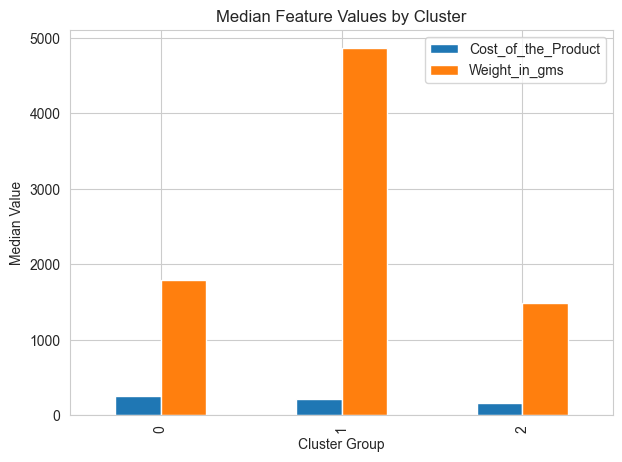

In [8]:
cluster_stats.plot(kind="bar", figsize=(7,5))

plt.title("Median Feature Values by Cluster")
plt.xlabel("Cluster Group")
plt.ylabel("Median Value")

plt.show()

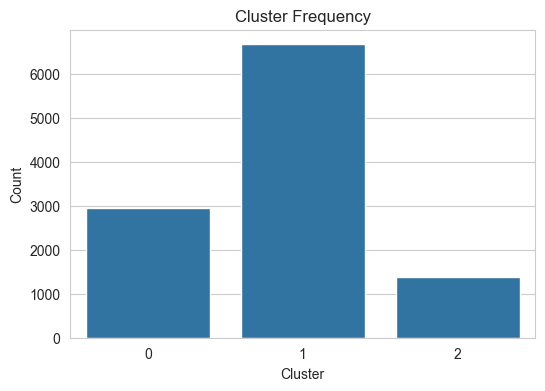

In [9]:
plt.figure(figsize=(6,4))

sns.barplot(x=data["Cluster_Group"].value_counts().index,
            y=data["Cluster_Group"].value_counts().values)

plt.title("Cluster Frequency")

plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

In [10]:
X_data = data.drop(columns=["Reached.on.Time_Y.N"])

y_target = data["Reached.on.Time_Y.N"]

X_data = pd.get_dummies(X_data)

In [11]:
selector = SelectKBest(score_func=mutual_info_classif, k=5)

selected_matrix = selector.fit_transform(X_data, y_target)

important_features = X_data.columns[selector.get_support()]

print("Selected Important Features:")
print(important_features)

Selected Important Features:
Index(['ID', 'Discount_offered', 'Weight_in_gms', 'Cluster_Group',
       'Warehouse_block_B'],
      dtype='object')
